In [39]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

from xgboost import XGBClassifier

from sdv.metadata import SingleTableMetadata
from sdv.single_table import CTGANSynthesizer

import tensorflow as tf
from tensorflow.keras import layers, models

In [40]:
df = pd.read_csv("03-02-2018.csv")

df.columns = df.columns.str.strip()

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

target_col = "Label"

print(df[target_col].value_counts())

Label
Benign    756762
Bot       282310
Name: count, dtype: int64


In [41]:
label_encoder = LabelEncoder()
df[target_col] = label_encoder.fit_transform(df[target_col])

joblib.dump(label_encoder, "label_encoder.pkl")

print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

PicklingError: Can't pickle <built-in function _reconstruct>: import of module 'numpy._core.multiarray' failed

In [42]:
df.columns = df.columns.str.strip()

# Remove timestamp columns
for col in df.columns:
    if "time" in col.lower() or "timestamp" in col.lower():
        df.drop(columns=[col], inplace=True)

# Remove duplicate columns
df = df.loc[:, ~df.columns.duplicated()]

# Remove known duplicate/problem column if present
if "Fwd Header Length.1" in df.columns:
    df.drop(columns=["Fwd Header Length.1"], inplace=True)

# Replace infinity values
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Remove null values
df.dropna(inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

print("Final shape:", df.shape)
print("Null values:", df.isnull().sum().sum())
print("Infinity values:", np.isinf(df.select_dtypes(include=[np.number])).sum().sum())
print("Duplicates:", df.duplicated().sum())

Final shape: (819904, 79)
Null values: 0
Infinity values: 0
Duplicates: 0


In [43]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import numpy as np
import joblib

target_col = "Label"

# Clean column names
df.columns = df.columns.str.strip()

# Remove Timestamp column if present
for col in df.columns:
    if "time" in col.lower() or "timestamp" in col.lower():
        df.drop(columns=[col], inplace=True)

# Separate X and y
X = df.drop(columns=[target_col])
y = df[target_col]

# Encode target if it is string
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

joblib.dump(label_encoder, "label_encoder.pkl")

# Convert all feature columns to numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Remove NaN and infinity
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)

# Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)

mi_df = pd.DataFrame({
    "Feature": X.columns,
    "MI_Score": mi_scores
}).sort_values(by="MI_Score", ascending=False)

top_k = int(len(X.columns) * 0.25)
selected_features = mi_df.head(top_k)["Feature"].tolist()

print("Selected Features:")
print(selected_features)

joblib.dump(selected_features, "selected_features.pkl")0

SyntaxError: invalid syntax (981244051.py, line 48)

In [44]:
df_selected = X[selected_features].copy()
df_selected[target_col] = y

print(df_selected.head())
print(df_selected[target_col].value_counts())

            Dst Port  Fwd IAT Max  Fwd IAT Mean  Fwd IAT Tot  Flow Pkts/s  \
743812     80.000000   54600000.0    54600000.0   54600000.0     0.036609   
1203925  8178.232422     -25308.0        5371.0     -18133.0  1028.267578   
498441     53.000000     134314.0      134314.0     134314.0    29.453780   
707250     53.000000          0.0           0.0          0.0  6644.518272   
764823     80.000000   54200000.0    54200000.0   54200000.0     0.036924   

         Flow IAT Mean   Fwd Pkts/s  Flow IAT Max  Flow Duration  Fwd IAT Min  \
743812    5.460000e+07     0.036609    54600000.0     54631838.0   54600000.0   
1203925  -6.566000e+03   539.744141      121430.5        40436.0      74452.0   
498441    4.526867e+04    14.726890      109119.0       135806.0     134314.0   
707250    3.010000e+02  3322.259136         301.0          301.0          0.0   
764823    5.420000e+07     0.036924    54200000.0     54165161.0   54200000.0   

         Pkt Len Max  Fwd Pkt Len Max  Fwd Seg Siz

In [45]:
import os
os.environ["JOBLIB_MULTIPROCESSING"] = "0"

In [46]:
df_selected = df_selected.copy()

# convert column names to string
df_selected.columns = df_selected.columns.astype(str)

# force all columns to simple Python-compatible types
for col in df_selected.columns:
    df_selected[col] = pd.to_numeric(df_selected[col], errors="coerce")

df_selected.replace([np.inf, -np.inf], np.nan, inplace=True)
df_selected.fillna(0, inplace=True)

# target should be integer category
df_selected[target_col] = df_selected[target_col].astype(int).astype(str)

print(df_selected.dtypes)

Dst Port            float64
Fwd IAT Max         float64
Fwd IAT Mean        float64
Fwd IAT Tot         float64
Flow Pkts/s         float64
Flow IAT Mean       float64
Fwd Pkts/s          float64
Flow IAT Max        float64
Flow Duration       float64
Fwd IAT Min         float64
Pkt Len Max         float64
Fwd Pkt Len Max     float64
Fwd Seg Size Avg    float64
Fwd Pkt Len Mean    float64
Pkt Len Mean        float64
Subflow Fwd Byts    float64
TotLen Fwd Pkts     float64
Pkt Len Std         float64
Pkt Size Avg        float64
Label                object
dtype: object


In [47]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

In [48]:
target_col = "Label"

X_gan = df_selected.drop(columns=[target_col])
y_gan = df_selected[target_col].astype(int)

scaler_gan = StandardScaler()
X_gan_scaled = scaler_gan.fit_transform(X_gan)

X_tensor = torch.tensor(X_gan_scaled, dtype=torch.float32)
y_tensor = torch.tensor(y_gan.values, dtype=torch.long)

dataset = TensorDataset(X_tensor, y_tensor)
loader = DataLoader(dataset, batch_size=256, shuffle=True)

input_dim = X_tensor.shape[1]
num_classes = len(np.unique(y_gan))
latent_dim = 64

In [49]:
class Generator(nn.Module):
    def __init__(self, latent_dim, num_classes, output_dim):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 128),
            nn.LeakyReLU(0.2),

            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, output_dim)
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([noise, label_input], dim=1)
        return self.model(x)

In [50]:
class Discriminator(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()

        self.label_emb = nn.Embedding(num_classes, num_classes)

        self.model = nn.Sequential(
            nn.Linear(input_dim + num_classes, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.3),

            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, data, labels):
        label_input = self.label_emb(labels)
        x = torch.cat([data, label_input], dim=1)
        return self.model(x)

In [51]:
generator = Generator(latent_dim, num_classes, input_dim)
discriminator = Discriminator(input_dim, num_classes)

criterion = nn.BCELoss()

g_optimizer = optim.Adam(generator.parameters(), lr=0.0002)
d_optimizer = optim.Adam(discriminator.parameters(), lr=0.0002)


In [52]:
epochs = 10

for epoch in range(epochs):
    for real_data, real_labels in loader:
        batch_size = real_data.size(0)

        valid = torch.ones(batch_size, 1)
        fake = torch.zeros(batch_size, 1)

        # Train Discriminator
        noise = torch.randn(batch_size, latent_dim)
        gen_labels = real_labels
        fake_data = generator(noise, gen_labels)

        real_output = discriminator(real_data, real_labels)
        fake_output = discriminator(fake_data.detach(), gen_labels)

        d_loss_real = criterion(real_output, valid)
        d_loss_fake = criterion(fake_output, fake)
        d_loss = d_loss_real + d_loss_fake

        d_optimizer.zero_grad()
        d_loss.backward()
        d_optimizer.step()

        # Train Generator
        noise = torch.randn(batch_size, latent_dim)
        gen_labels = real_labels
        fake_data = generator(noise, gen_labels)

        output = discriminator(fake_data, gen_labels)
        g_loss = criterion(output, valid)

        g_optimizer.zero_grad()
        g_loss.backward()
        g_optimizer.step()

    print(f"Epoch [{epoch+1}/{epochs}] | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch [1/10] | D Loss: 1.1719 | G Loss: 0.8864
Epoch [2/10] | D Loss: 1.2345 | G Loss: 0.9126
Epoch [3/10] | D Loss: 1.0748 | G Loss: 1.0621
Epoch [4/10] | D Loss: 1.2052 | G Loss: 0.8770
Epoch [5/10] | D Loss: 1.1967 | G Loss: 0.9367
Epoch [6/10] | D Loss: 1.2257 | G Loss: 0.8517
Epoch [7/10] | D Loss: 0.8324 | G Loss: 1.2496
Epoch [8/10] | D Loss: 1.2071 | G Loss: 0.9398
Epoch [9/10] | D Loss: 1.1459 | G Loss: 0.9757
Epoch [10/10] | D Loss: 1.2011 | G Loss: 0.9088


In [53]:
class_counts = df_selected[target_col].value_counts()
max_count = class_counts.max()

synthetic_parts = [df_selected]

for class_label, count in class_counts.items():
    needed = max_count - count

    if needed > 0:
        noise = torch.randn(needed, latent_dim)
        labels = torch.full((needed,), int(class_label), dtype=torch.long)

        synthetic_scaled = generator(noise, labels).detach().numpy()
        synthetic_original = scaler_gan.inverse_transform(synthetic_scaled)

        synthetic_df = pd.DataFrame(synthetic_original, columns=X_gan.columns)
        synthetic_df[target_col] = int(class_label)

        synthetic_parts.append(synthetic_df)

balanced_df = pd.concat(synthetic_parts, axis=0).sample(frac=1, random_state=42)

print(balanced_df[target_col].value_counts())

Label
0    660009
1    618427
1     41582
Name: count, dtype: int64


In [54]:
balanced_df.to_csv("gan_balanced_dataset.csv", index=False)

torch.save(generator.state_dict(), "conditional_gan_generator.pth")
torch.save(discriminator.state_dict(), "conditional_gan_discriminator.pth")

In [55]:
class_counts = df_selected[target_col].value_counts()
max_count = class_counts.max()

synthetic_parts = [df_selected]

for class_label, count in class_counts.items():
    needed = max_count - count

    if needed > 0:
        noise = torch.randn(needed, latent_dim)
        labels = torch.full((needed,), int(class_label), dtype=torch.long)

        synthetic_scaled = generator(noise, labels).detach().numpy()
        synthetic_original = scaler_gan.inverse_transform(synthetic_scaled)

        synthetic_df = pd.DataFrame(
            synthetic_original,
            columns=X_gan.columns
        )

        synthetic_df[target_col] = int(class_label)

        synthetic_parts.append(synthetic_df)

balanced_df = pd.concat(synthetic_parts, axis=0)

print(balanced_df[target_col].value_counts())

Label
0    660009
1    618427
1     41582
Name: count, dtype: int64


In [56]:
print(df_selected[target_col].unique())
print(df_selected[target_col].dtype)

['0' '1']
object


In [57]:
class_counts = df_selected[target_col].value_counts()
max_count = class_counts.max()

synthetic_parts = []

# Add original data first
synthetic_parts.append(df_selected)

for class_label in class_counts.index:

    current_count = class_counts[class_label]
    needed = max_count - current_count

    print(f"Class {class_label} needs {needed} synthetic samples")

    if needed > 0:

        noise = torch.randn(needed, latent_dim)

        labels = torch.full(
            (needed,),
            int(class_label),
            dtype=torch.long
        )

        synthetic_scaled = generator(
            noise,
            labels
        ).detach().numpy()

        synthetic_original = scaler_gan.inverse_transform(
            synthetic_scaled
        )

        synthetic_df = pd.DataFrame(
            synthetic_original,
            columns=X_gan.columns
        )

        synthetic_df[target_col] = int(class_label)

        synthetic_parts.append(synthetic_df)

balanced_df = pd.concat(
    synthetic_parts,
    axis=0,
    ignore_index=True
)

balanced_df = balanced_df.sample(
    frac=1,
    random_state=42
)

print("\nBalanced Dataset Distribution:\n")
print(balanced_df[target_col].value_counts())

Class 0 needs 0 synthetic samples
Class 1 needs 41582 synthetic samples

Balanced Dataset Distribution:

Label
0    660009
1    618427
1     41582
Name: count, dtype: int64


In [58]:
balanced_df[target_col] = balanced_df[target_col].astype(int)

print(balanced_df[target_col].value_counts())

Label
0    660009
1    660009
Name: count, dtype: int64


In [59]:
balanced_df.to_csv("gan_balanced_dataset.csv", index=False)

In [60]:
print(
    balanced_df[target_col]
    .value_counts(normalize=True) * 100
)

Label
0    50.0
1    50.0
Name: proportion, dtype: float64


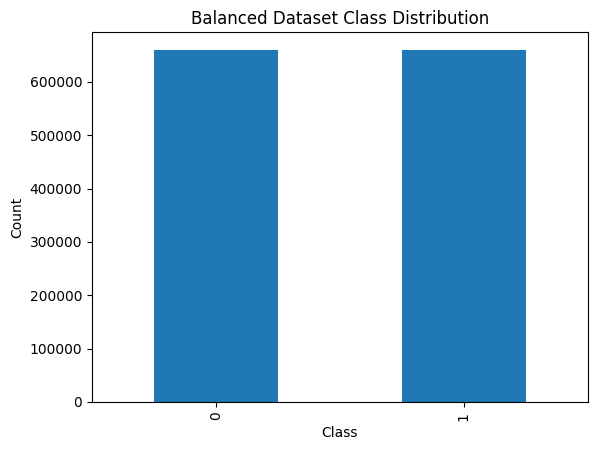

In [61]:
import matplotlib.pyplot as plt

balanced_df[target_col].value_counts().plot(
    kind="bar"
)

plt.title("Balanced Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

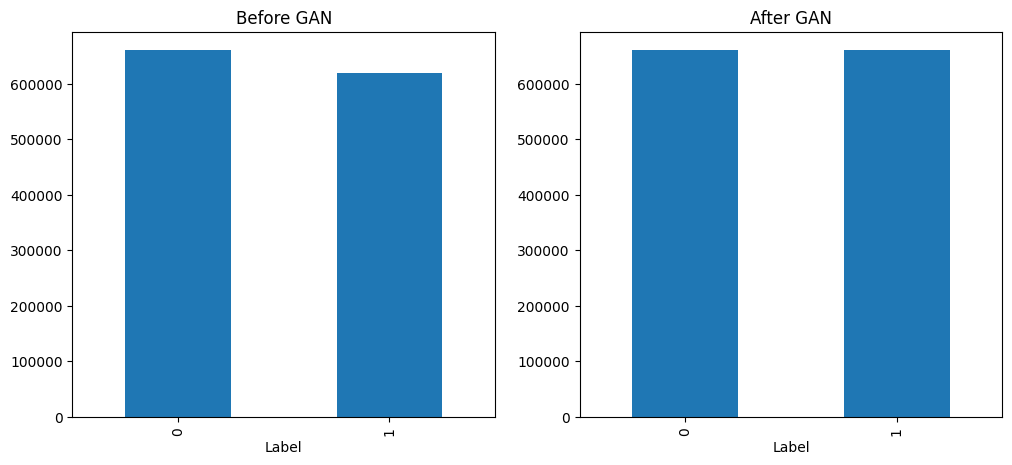

In [62]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df_selected[target_col].value_counts().plot(
    kind="bar",
    ax=axes[0],
    title="Before GAN"
)

balanced_df[target_col].value_counts().plot(
    kind="bar",
    ax=axes[1],
    title="After GAN"
)

plt.show()

In [65]:
target_col = "Label"

X = balanced_df.drop(columns=[target_col])
y = balanced_df[target_col]

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [67]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

joblib.dump(scaler, "xgb_scaler.pkl")

PicklingError: Can't pickle <built-in function _reconstruct>: import of module 'numpy._core.multiarray' failed

In [68]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",   # because you currently have labels 0 and 1
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9999621217860335
F1 Score: 0.9999621223599285
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132002
           1       1.00      1.00      1.00    132002

    accuracy                           1.00    264004
   macro avg       1.00      1.00      1.00    264004
weighted avg       1.00      1.00      1.00    264004

[[131995      7]
 [     3 131999]]


In [69]:
# 1. Check duplicate rows after GAN
print("Duplicates:", balanced_df.duplicated().sum())

Duplicates: 0


In [70]:
# 2. Train-test split should happen AFTER balancing, but avoid duplicate leakage
balanced_df = balanced_df.drop_duplicates()

X = balanced_df.drop(columns=[target_col])
y = balanced_df[target_col]

In [71]:
# 3. Check if any label-like column exists inside features
for col in X.columns:
    if "label" in col.lower() or "attack" in col.lower() or "class" in col.lower():
        print("Possible leakage column:", col)

In [72]:
print(balanced_df[target_col].value_counts())

Label
0    660009
1    660009
Name: count, dtype: int64


In [73]:
X = balanced_df.drop(columns=[target_col])
y = balanced_df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

xgb_model.fit(X_train_scaled, y_train)

y_pred = xgb_model.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9999621217860335
F1 Score: 0.9999621223599285
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    132002
           1       1.00      1.00      1.00    132002

    accuracy                           1.00    264004
   macro avg       1.00      1.00      1.00    264004
weighted avg       1.00      1.00      1.00    264004

[[131995      7]
 [     3 131999]]


Now This is Auto Encoder Part .

In [74]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

In [75]:
target_col = "Label"

# Train Autoencoder only on BENIGN traffic
benign_df = balanced_df[balanced_df[target_col] == 0]

X_benign = benign_df.drop(columns=[target_col])

ae_scaler = StandardScaler()
X_benign_scaled = ae_scaler.fit_transform(X_benign)

X_train_ae, X_val_ae = train_test_split(
    X_benign_scaled,
    test_size=0.2,
    random_state=42
)

In [76]:
input_dim = X_train_ae.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),

    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

history = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=30,
    batch_size=256,
    shuffle=True
)

Epoch 1/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0868 - val_loss: 0.0352
Epoch 2/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0704 - val_loss: 0.1315
Epoch 3/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0651 - val_loss: 0.0170
Epoch 4/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0664 - val_loss: 0.0359
Epoch 5/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0323 - val_loss: 0.0399
Epoch 6/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0554 - val_loss: 0.0430
Epoch 7/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0355 - val_loss: 0.0540
Epoch 8/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0630 - val_loss: 0.0263
Epoch 9/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0524 - val_loss: 0.0263
Epoch 10/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0408 - val_loss: 0.0157
Epoch 11/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0384 - val_loss: 0.0209
Epoch 12/30
2063/2063 ━━━━━━━━

In [77]:
reconstructed = autoencoder.predict(X_val_ae)

mse = np.mean(np.square(X_val_ae - reconstructed), axis=1)

threshold = np.percentile(mse, 95)

print("Autoencoder Threshold:", threshold)

4126/4126 ━━━━━━━━━━━━━━━━━━━━ 2s 573us/step
Autoencoder Threshold: 0.04484731881354908


In [78]:
# Prepare full test data
X_all = balanced_df.drop(columns=[target_col])
y_all = balanced_df[target_col].astype(int)

X_all_scaled = ae_scaler.transform(X_all)

# Reconstruct all samples
reconstructed_all = autoencoder.predict(X_all_scaled)

# Calculate reconstruction error
mse_all = np.mean(np.square(X_all_scaled - reconstructed_all), axis=1)

# Prediction by Autoencoder
ae_preds = (mse_all > threshold).astype(int)

# 0 = Benign, 1 = Anomaly/Attack
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("Autoencoder Accuracy:", accuracy_score(y_all, ae_preds))
print(classification_report(y_all, ae_preds))
print(confusion_matrix(y_all, ae_preds))

41251/41251 ━━━━━━━━━━━━━━━━━━━━ 28s 667us/step
Autoencoder Accuracy: 0.4755048794789162
              precision    recall  f1-score   support

           0       0.49      0.95      0.64    660009
           1       0.01      0.00      0.00    660009

    accuracy                           0.48   1320018
   macro avg       0.25      0.48      0.32   1320018
weighted avg       0.25      0.48      0.32   1320018

[[627205  32804]
 [659539    470]]


In [79]:
def final_hybrid_predict(sample_df):
    # XGBoost known attack detection
    X_sample = sample_df.drop(columns=[target_col], errors="ignore")
    X_sample_scaled = scaler.transform(X_sample)

    xgb_pred = xgb_model.predict(X_sample_scaled)
    xgb_prob = xgb_model.predict_proba(X_sample_scaled)

    results = []

    for i in range(len(sample_df)):
        label = int(xgb_pred[i])
        confidence = float(np.max(xgb_prob[i]))

        if label == 1:
            results.append({
                "result": "Known Attack",
                "attack_type": "Attack",
                "confidence": confidence
            })
        else:
            # Autoencoder check
            one_sample = X_sample.iloc[[i]]
            one_scaled = ae_scaler.transform(one_sample)

            recon = autoencoder.predict(one_scaled)
            error = np.mean(np.square(one_scaled - recon))

            if error > threshold:
                results.append({
                    "result": "Unknown Attack",
                    "attack_type": "Unknown / Zero-Day",
                    "reconstruction_error": float(error)
                })
            else:
                results.append({
                    "result": "Benign",
                    "attack_type": "None",
                    "confidence": confidence
                })

    return results

In [80]:
sample_data = balanced_df.sample(10, random_state=42)

final_results = final_hybrid_predict(sample_data)

for r in final_results:
    print(r)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
{'result': 'Benign', 'attack_type': 'None', 'confidence': 0.9999977946281433}
{'result': 'Benign', 'attack_type': 'None', 'confidence': 0.999997615814209}
{'result': 'Known Attack', 'attack_type': 'Attack', 'confidence': 0.9999986886978149}
{'result': 'Known Attack', 'attack_type': 'Attack', 'confidence': 0.9999983310699463}
{'result': 'Known Attack', 'attack_type': 'Attack', 'confidence': 0.9999974966049194}
{'result': 'Known Attack', 'attack_type': 'Attack', 'confidence': 0.9999986886978149}
{'result': 'Known Attack', 'attack_type': 'Attack', 'confidence': 0.9999985694885254}
{'result': 'Benign', 'attack_type': 'None', 'confidence': 0.9999983310699463}
{'result': 'Unknown Attack', 'attack_type': 'Unknown / Zero-Day', 'reconstruction_error': 0.1120228427778529}
{'result': 'Benign', 'attack_type': '

In [82]:
print(df_selected[target_col].value_counts())
print(df_selected[target_col].unique())

Label
0    660009
1    618427
Name: count, dtype: int64
['0' '1']


In [83]:
print(label_encoder.classes_)

['Benign' 'Bot']


In [86]:
target_col = "Label"

# Convert labels to integer
df_selected[target_col] = df_selected[target_col].astype(int)

# In your encoder, Benign = 0, Bot = 1
benign_label = 0

benign_df = df_selected[df_selected[target_col] == benign_label]

print("Benign rows:", len(benign_df))
print(benign_df[target_col].value_counts())

Benign rows: 660009
Label
0    660009
Name: count, dtype: int64


In [87]:
X_benign = benign_df.drop(columns=[target_col])

ae_scaler = StandardScaler()
X_benign_scaled = ae_scaler.fit_transform(X_benign)

Retraining the Autoencoder

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np

In [89]:
X_train_ae, X_val_ae = train_test_split(
    X_benign_scaled,
    test_size=0.2,
    random_state=42
)

input_dim = X_train_ae.shape[1]

autoencoder = models.Sequential([
    layers.Input(shape=(input_dim,)),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(64, activation="relu"),
    layers.Dense(32, activation="relu"),

    layers.Dense(16, activation="relu"),

    layers.Dense(32, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),

    layers.Dense(input_dim, activation="linear")
])

autoencoder.compile(
    optimizer="adam",
    loss="mse"
)

history = autoencoder.fit(
    X_train_ae,
    X_train_ae,
    validation_data=(X_val_ae, X_val_ae),
    epochs=30,
    batch_size=256,
    shuffle=True
)

Epoch 1/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0659 - val_loss: 0.0495
Epoch 2/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0650 - val_loss: 0.0163
Epoch 3/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0271 - val_loss: 0.0174
Epoch 4/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0203 - val_loss: 0.0233
Epoch 5/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0352 - val_loss: 0.0718
Epoch 6/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0272 - val_loss: 0.0126
Epoch 7/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0270 - val_loss: 0.0144
Epoch 8/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0181 - val_loss: 4.2861
Epoch 9/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0399 - val_loss: 0.0839
Epoch 10/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0196 - val_loss: 0.0247
Epoch 11/30
2063/2063 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0524 - val_loss: 0.0145
Epoch 12/30
2063/2063 ━━━━━━━━

In [90]:
reconstructed = autoencoder.predict(X_val_ae)

mse = np.mean(np.square(X_val_ae - reconstructed), axis=1)

threshold = np.percentile(mse, 95)

print("Autoencoder Threshold:", threshold)

4126/4126 ━━━━━━━━━━━━━━━━━━━━ 3s 626us/step
Autoencoder Threshold: 0.0653160297954937


In [91]:
X_all = df_selected.drop(columns=[target_col])
y_all = df_selected[target_col].astype(int)

X_all_scaled = ae_scaler.transform(X_all)

reconstructed_all = autoencoder.predict(X_all_scaled)

mse_all = np.mean(np.square(X_all_scaled - reconstructed_all), axis=1)

ae_preds = (mse_all > threshold).astype(int)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Autoencoder Accuracy:", accuracy_score(y_all, ae_preds))
print(classification_report(y_all, ae_preds))
print(confusion_matrix(y_all, ae_preds))

39952/39952 ━━━━━━━━━━━━━━━━━━━━ 25s 616us/step
Autoencoder Accuracy: 0.49036166065411174
              precision    recall  f1-score   support

           0       0.50      0.95      0.66    660009
           1       0.00      0.00      0.00    618427

    accuracy                           0.49   1278436
   macro avg       0.25      0.47      0.33   1278436
weighted avg       0.26      0.49      0.34   1278436

[[626770  33239]
 [618301    126]]


In [92]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import numpy as np

In [93]:
target_col = "Label"

# Make sure labels are integer
df_selected[target_col] = df_selected[target_col].astype(int)

# Benign = 0
benign_df = df_selected[df_selected[target_col] == 0]

X_benign = benign_df.drop(columns=[target_col])

iso_scaler = StandardScaler()
X_benign_scaled = iso_scaler.fit_transform(X_benign)

iso_model = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)

iso_model.fit(X_benign_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",200
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary ` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary `.",42
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary `... versionadded:: 0.21",False


In [94]:
X_all = df_selected.drop(columns=[target_col])
y_all = df_selected[target_col].astype(int)

X_all_scaled = iso_scaler.transform(X_all)

iso_raw_preds = iso_model.predict(X_all_scaled)

# Isolation Forest gives:
#  1 = normal
# -1 = anomaly
iso_preds = np.where(iso_raw_preds == -1, 1, 0)

print("Isolation Forest Accuracy:", accuracy_score(y_all, iso_preds))
print(classification_report(y_all, iso_preds))
print(confusion_matrix(y_all, iso_preds))

Isolation Forest Accuracy: 0.49049698225018695
              precision    recall  f1-score   support

           0       0.50      0.95      0.66    660009
           1       0.00      0.00      0.00    618427

    accuracy                           0.49   1278436
   macro avg       0.25      0.48      0.33   1278436
weighted avg       0.26      0.49      0.34   1278436

[[627010  32999]
 [618368     59]]


In [95]:
def hybrid_predict(sample_df):
    X_sample = sample_df.drop(columns=[target_col], errors="ignore")

    # XGBoost known attack detection
    X_xgb = scaler.transform(X_sample)
    xgb_pred = xgb_model.predict(X_xgb)
    xgb_prob = xgb_model.predict_proba(X_xgb)

    results = []

    for i in range(len(sample_df)):
        pred = int(xgb_pred[i])
        confidence = float(np.max(xgb_prob[i]))

        if pred == 1:
            results.append({
                "result": "Known Attack",
                "attack_type": "Attack",
                "confidence": confidence
            })

        else:
            one_sample = X_sample.iloc[[i]]
            one_scaled = iso_scaler.transform(one_sample)

            iso_pred = iso_model.predict(one_scaled)[0]

            if iso_pred == -1:
                results.append({
                    "result": "Unknown Attack / Anomaly",
                    "attack_type": "Unknown",
                    "method": "Isolation Forest"
                })
            else:
                results.append({
                    "result": "Benign",
                    "attack_type": "None",
                    "confidence": confidence
                })

    return results